In [1]:
from google import genai
from google.colab import userdata

In [2]:
import pandas as pd
df = pd.read_csv("/content/cluster_summaries_layer2.csv")

In [3]:

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))


client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

In [4]:
all_data = []
full_embedding_list = []

for i, row in df.iterrows():
    data_dict = {}

    ind = row['cluster_label']
    failed_summary = row['cluster_summary']

    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=failed_summary)

    embedding_for_clustering = result.embeddings[0].values
    full_embedding_list.append(embedding_for_clustering)

    data_dict['cluster_label'] = ind
    data_dict['cluster_summary'] = failed_summary
    data_dict['embedding_for_clustering'] = embedding_for_clustering

    all_data.append(data_dict)

In [5]:
import numpy as np

embeddings_np_array = np.array(full_embedding_list)

print(f"Shape of multiple embeddings array: {embeddings_np_array.shape}")

Shape of multiple embeddings array: (80, 3072)


In [6]:
from sklearn.cluster import KMeans

# Perform K-Means clustering
# With only one data point, n_clusters can be 1
kmeans = KMeans(n_clusters=10, random_state=0, n_init='auto')
kmeans.fit(embeddings_np_array)

KMeans(n_clusters=10, random_state=0)

In [7]:
# Get the cluster label for the data point
cluster_label = kmeans.labels_

In [8]:
final_dicts = []

for c_label, d_dict in zip(cluster_label, all_data):
    update_d = {}

    # Convert numpy.int32 to a standard Python int
    update_d['cluster_label'] = int(c_label)
    update_d['round1_cluster_label'] = d_dict['cluster_label']
    update_d['cluster_summary'] = d_dict['cluster_summary']
    update_d['embedding_for_clustering'] = d_dict['embedding_for_clustering']

    final_dicts.append(update_d)

In [9]:
import json

output_filename = 'clustered_data.json'

with open(output_filename, 'w') as f:
    json.dump(final_dicts, f, indent=4)

print(f"Clustered data saved to {output_filename}")

Clustered data saved to clustered_data.json


In [10]:
clustered_data_separated = {}

for item in final_dicts:
    cluster_id = item['cluster_label']
    if cluster_id not in clustered_data_separated:
        clustered_data_separated[cluster_id] = []
    clustered_data_separated[cluster_id].append(item)

if clustered_data_separated:
    first_cluster_id = list(clustered_data_separated.keys())[0]
    print(f"Data for Cluster {first_cluster_id}:\n")
    # Display the first few items of the first cluster for demonstration
    for i, data_item in enumerate(clustered_data_separated[first_cluster_id]):
        if i >= 2: # Limit to first 3 items for brevity
            break

print(f"Total unique clusters found: {len(clustered_data_separated)}")

Data for Cluster 6:

Total unique clusters found: 10


In [11]:
output_filename = 'clustered_data_separated.json'

with open(output_filename, 'w') as f:
    json.dump(clustered_data_separated, f, indent=4)

print(f"Clustered data saved to {output_filename}")

Clustered data saved to clustered_data_separated.json


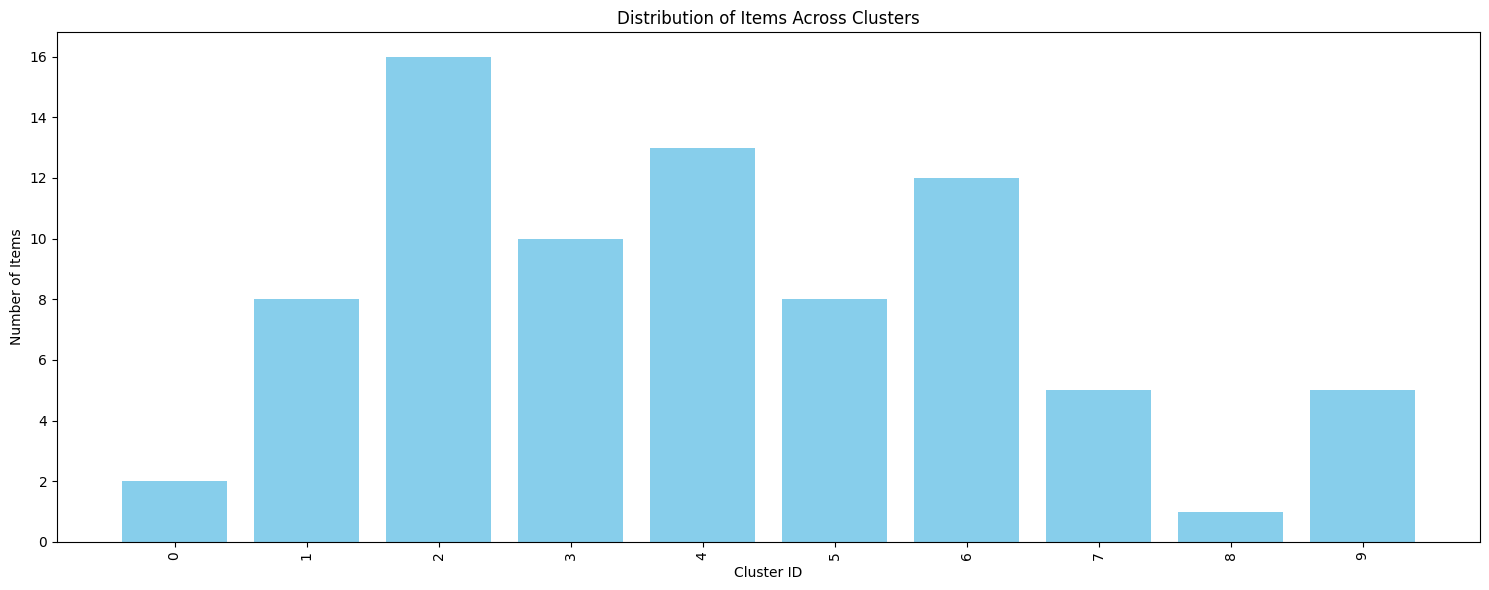

In [12]:
import matplotlib.pyplot as plt

# Calculate the size of each cluster
cluster_sizes = {cluster_id: len(data_list) for cluster_id, data_list in clustered_data_separated.items()}

# Sort clusters by ID for consistent plotting
sorted_cluster_sizes = sorted(cluster_sizes.items())
cluster_ids = [str(item[0]) for item in sorted_cluster_sizes]
sizes = [item[1] for item in sorted_cluster_sizes]

plt.figure(figsize=(15, 6))
plt.bar(cluster_ids, sizes, color='skyblue')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.title('Distribution of Items Across Clusters')
plt.xticks(rotation=90) # Rotate x-axis labels if there are many clusters
plt.tight_layout()
plt.show()

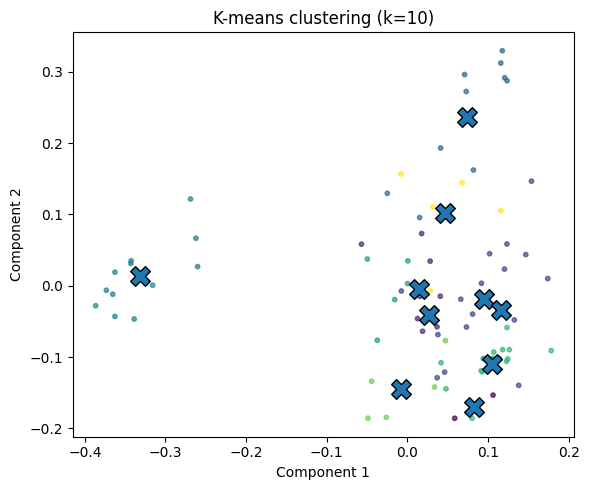

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


def plot_kmeans_clusters(embeddings: np.ndarray, kmeans: KMeans):
    """
    Plot k-means clustering result.

    - If embeddings are 2D, plot directly.
    - If embeddings are >2D, reduce to 2D using PCA and plot.
    """
    assert embeddings.ndim == 2, "embeddings must be 2D: (n_samples, n_features)"
    labels = kmeans.labels_

    n_features = embeddings.shape[1]

    if n_features == 2:
        # Directly plot 2D embeddings
        X2 = embeddings
        centers_2d = kmeans.cluster_centers_
    else:
        # Use a single PCA object for both points and centers
        pca = PCA(n_components=2)
        X2 = pca.fit_transform(embeddings)
        centers_2d = pca.transform(kmeans.cluster_centers_)

    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels,  s=10, alpha=0.7)

    plt.scatter(
        centers_2d[:, 0],
        centers_2d[:, 1],
        marker="X",
        s=200,
        edgecolor="black",
        linewidth=1.0,
    )

    plt.title(f"K-means clustering (k={kmeans.n_clusters})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

plot_kmeans_clusters(embeddings_np_array, kmeans)

In [14]:
import joblib

# Save the trained KMeans model
joblib.dump(kmeans, 'kmeans_model.joblib')
print("K-Means model saved as 'kmeans_model.joblib'")

# To load it back later:
# loaded_kmeans_model = joblib.load('kmeans_model.joblib')

K-Means model saved as 'kmeans_model.joblib'
